In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from collections import Counter
from tensorflow.keras.datasets import cifar10, cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# Loading datasets 

In [8]:
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")

x_validation = np.load("x_validation.npy")
y_validation = np.load("y_validation.npy")

x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

ValueError: Failed to read all data for array. Expected (9100, 24, 24, 24, 24) = 3019161600 elements, could only read 805306368 elements. (file seems not fully written?)

## Verifying the datasets

In [6]:
num_classes = 24

y_test = to_categorical(
    y_test,
    num_classes=num_classes
)

print("Test labels after encoding:", y_test.shape)

NameError: name 'y_test' is not defined

In [7]:
np.save("y_test.npy", y_test)

NameError: name 'y_test' is not defined

In [16]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("\nValidation images:", x_validation.shape)
print("Validation labels:", y_validation.shape)

print("\nTest images:", x_test.shape)
print("Test labels:", y_test.shape)

print("\nTraining pixel range:")
print("Min:", x_train.min(), "Max:", x_train.max())

Training images: (36400, 32, 32, 3)
Training labels: (36400, 24)

Validation images: (9100, 32, 32, 3)
Validation labels: (9100, 24)

Test images: (9100, 32, 32, 3)
Test labels: (9100, 24, 24, 24)

Training pixel range:
Min: 0.0 Max: 1.0


# Final classes

In [5]:
final_classes = [
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor",
    "trees"
]
num_classes = len(final_classes)

print("\nNumber of classes:", num_classes)


Number of classes: 24


# Building baseline CNN

In [6]:
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(24, activation='softmax')
])

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,616 (744.59 KB)

 Trainable params: 190,616 (744.59 KB)

 Non-trainable params: 0 (0.00 B)

# Training Model

In [11]:
history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_validation, y_validation),
    verbose=1,
)

Epoch 1/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3502 - loss: 2.1117 - val_accuracy: 0.4333 - val_loss: 1.8180
Epoch 2/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4716 - loss: 1.7220 - val_accuracy: 0.4941 - val_loss: 1.6846
Epoch 3/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5195 - loss: 1.5547 - val_accuracy: 0.5342 - val_loss: 1.5293
Epoch 4/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5538 - loss: 1.4350 - val_accuracy: 0.5654 - val_loss: 1.4224
Epoch 5/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5862 - loss: 1.3298 - val_accuracy: 0.5602 - val_loss: 1.4633
Epoch 6/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6071 - loss: 1.2583 - val_accuracy: 0.5814 - val_loss: 1.3720
Epoch 7/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6258 - loss: 1.1893 - val_accuracy: 0.5880 - val_loss: 1.3443
Epoch 8/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6479 - loss: 1.1214 - val_accuracy

# Plotting training results

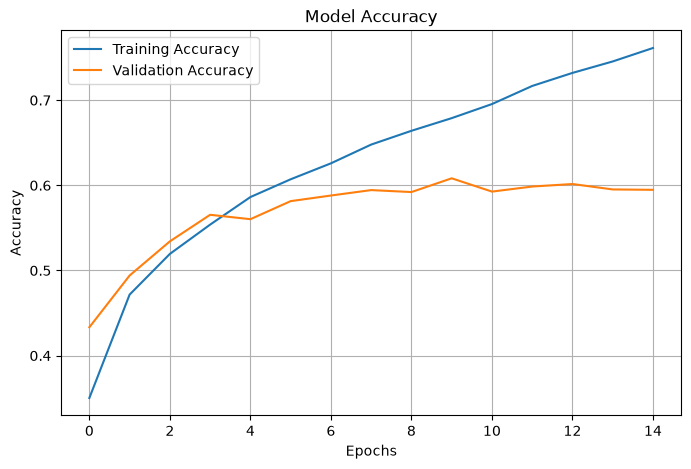

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')

plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.grid(True)
plt.show()

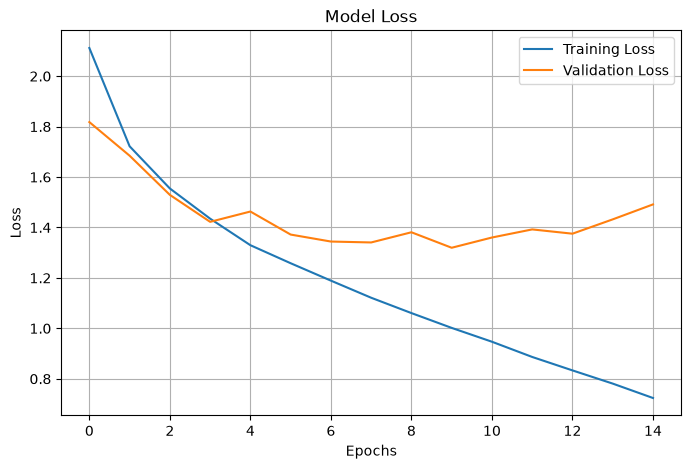

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['loss'], label='Training Loss')

plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.grid(True)
plt.show()

# Evaluating test set

In [17]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

ValueError: Cannot take the length of shape with unknown rank.

In [18]:
final_train_accuracy = history_baseline.history['accuracy'][-1]
final_validation_accuracy = history_baseline.history['val_accuracy'][-1]

final_train_loss = history_baseline.history['loss'][-1]
final_validation_loss = history_baseline.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_validation_accuracy:.4f}")

print(f"\nFinal Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_validation_loss:.4f}")

print(f"\nAccuracy gap:"
      f" {final_train_accuracy - final_validation_accuracy:.4f}")
print(f"Loss gap:"
      f" {final_train_loss - final_validation_loss:.4f}")

Final Training Accuracy: 0.7613
Final Validation Accuracy: 0.5947

Final Training Loss: 0.7239
Final Validation Loss: 1.4915

Accuracy gap: 0.1666
Loss gap: -0.7676


In [16]:
predictions = baseline_model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=final_classes))

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:


ValueError: Classification metrics can't handle a mix of multiclass-multioutput and multiclass targets

In [17]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(num_classes), final_classes, rotation=90)
plt.yticks(np.arange(num_classes), final_classes)

plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.tight_layout()
plt.show()

ValueError: Classification metrics can't handle a mix of multiclass-multioutput and multiclass targets

In [ ]:
baseline_model.save("baseline_cnn.keras")
print("Model saved as 'baseline_cnn.keras'")

Model saved as 'baseline_cnn.keras'


# Improved Model

In [ ]:
improved_model = Sequential([
    Conv2D(32, (3, 3), 
           padding='same', 
           activation='relu', 
           input_shape=(32, 32, 3)),

    BatchNormalization(),
    Conv2D(32, (3, 3), 
           padding='same',
           activation='relu'),

    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3),
              padding='same',
              activation='relu'),

    BatchNormalization(),
    Conv2D(64, (3, 3),
                padding='same',
                activation='relu'),

    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax'
    )])


In [ ]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122,360 (4.28 MB)

 Trainable params: 1,121,464 (4.28 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_improved = improved_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_validation, y_validation),
    callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1)

Epoch 1/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.3919 - loss: 2.1731 - val_accuracy: 0.3796 - val_loss: 2.1473
Epoch 2/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.5271 - loss: 1.5467 - val_accuracy: 0.5711 - val_loss: 1.3945
Epoch 3/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.5840 - loss: 1.3476 - val_accuracy: 0.5827 - val_loss: 1.3813
Epoch 4/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - accuracy: 0.6106 - loss: 1.2447 - val_accuracy: 0.5922 - val_loss: 1.3869
Epoch 5/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.6410 - loss: 1.1463 - val_accuracy: 0.6563 - val_loss: 1.1598
Epoch 6/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 36s 63ms/step - accuracy: 0.6583 - loss: 1.0911 - val_accuracy: 0.6362 - val_loss: 1.1796
Epoch 7/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.6774 - loss: 1.0236 - val_accuracy: 0.6720 - val_loss: 1.0765
Epoch 8/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.6860 - loss: 0.9950 - 

# Evaluating improved model

In [ ]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(x_test, y_test, verbose=1)

print(f"Improved Model Test Loss: {improved_test_loss:.4f}")
print(f"Improved Model Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Improved Model Test Accuracy: {improved_test_accuracy * 100:.2f}%")

285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7208 - loss: 0.9079
Improved Model Test Loss: 0.9079
Improved Model Test Accuracy: 0.7208
Improved Model Test Accuracy: 72.08%


# Plotting improved model history


## Accuracy graph

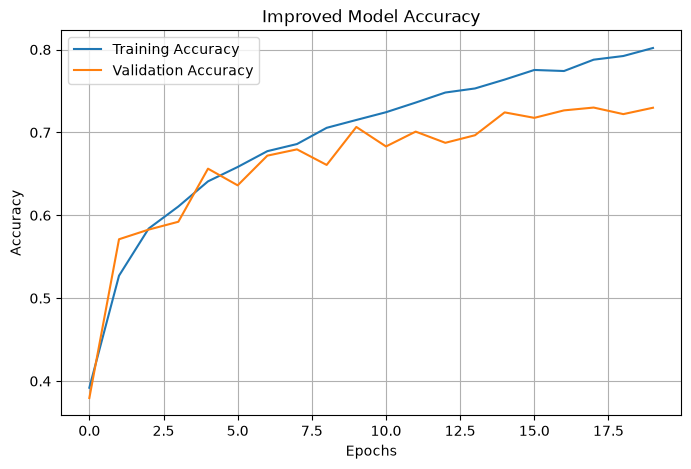

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['accuracy'], label='Training Accuracy')

plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Improved Model Accuracy')

plt.legend()
plt.grid(True)
plt.show()

## Loss Graph

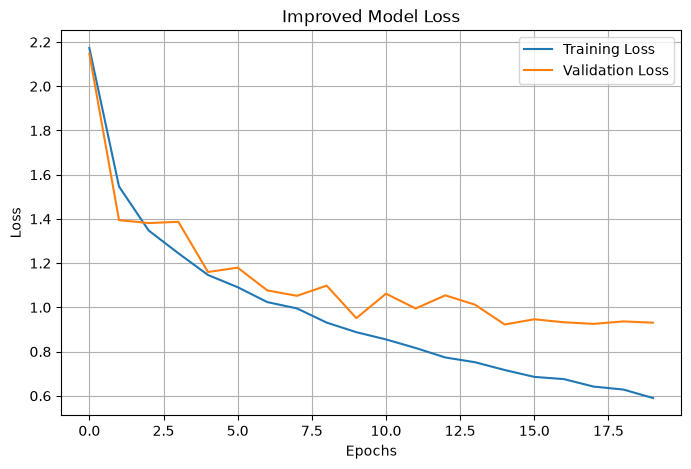

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Improved Model Loss')

plt.legend()
plt.grid(True)
plt.show()

# Comparing results of the Baseline Model and the Improved Model

In [ ]:
baseline_accuracy = 0.6147

print("Model Comparison:")
print(f"Baseline Accuracy: {baseline_accuracy* 100:.2f}%")
print(f"Improved Model Accuracy: {improved_test_accuracy * 100:.2f}%")

accuracy_change = improved_test_accuracy - baseline_accuracy
print(f"Accuracy Change: {accuracy_change * 100:.2f}%")

Model Comparison:
Baseline Accuracy: 61.47%
Improved Model Accuracy: 72.08%
Accuracy Change: 10.61%


In [ ]:
improved_model.save("improved_cnn.keras")
print("Improved model saved as 'improved_cnn.keras'")

Improved model saved as 'improved_cnn.keras'


# Improved Model predictions

In [ ]:
improved_probabilities = improved_model.predict(x_test)

improved_predicted_labels = np.argmax(improved_probabilities, axis=1)

true_labels = np.argmax(y_test, axis=1)


285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


# Clasification Report

In [ ]:
print("\nClassification Report for Improved Model:")
print(classification_report(true_labels, improved_predicted_labels, target_names=final_classes, digits=4))


Classification Report for Improved Model:
              precision    recall  f1-score   support

  automobile     0.9064    0.8520    0.8784      1000
        bird     0.7619    0.7390    0.7503      1000
         cat     0.5916    0.6650    0.6262      1000
        deer     0.6265    0.8740    0.7299      1000
         dog     0.6552    0.7220    0.6870      1000
       horse     0.8474    0.8220    0.8345      1000
       truck     0.7665    0.8960    0.8262      1000
      cattle     0.7692    0.1000    0.1770       100
         fox     0.5143    0.1800    0.2667       100
        baby     0.3944    0.2800    0.3275       100
         boy     0.3924    0.3100    0.3464       100
        girl     0.3919    0.2900    0.3333       100
         man     0.4808    0.2500    0.3289       100
       woman     0.3023    0.1300    0.1818       100
      rabbit     0.3333    0.0700    0.1157       100
    squirrel     0.3793    0.2200    0.2785       100
     bicycle     0.8906    0.9280    0

# Confusion Matrix


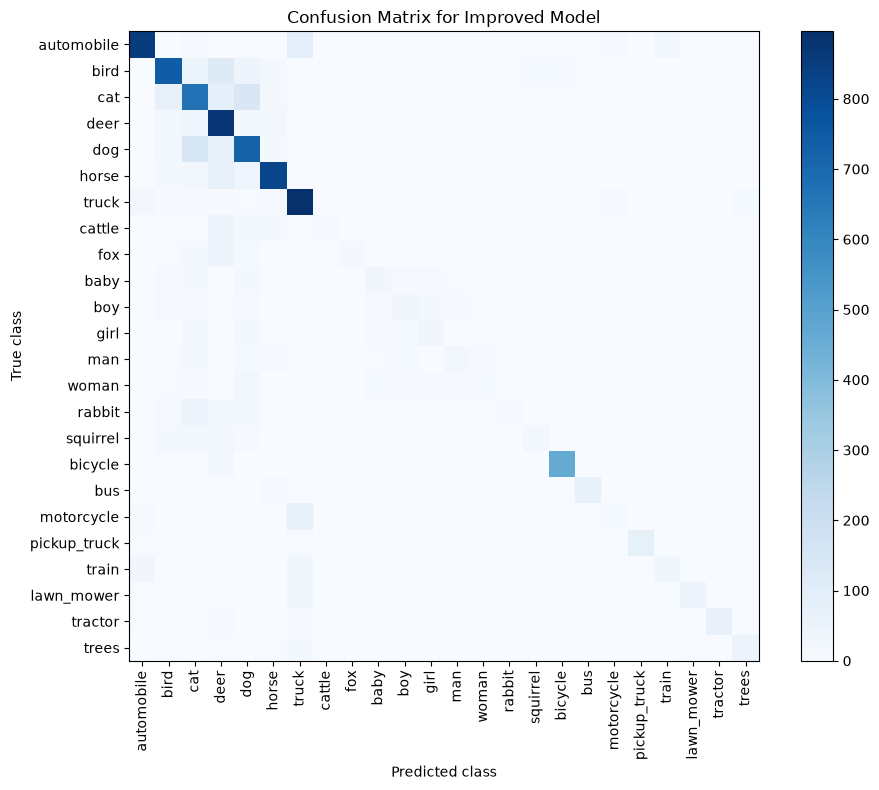

In [ ]:
improved_cm = confusion_matrix(true_labels, improved_predicted_labels)

plt.figure(figsize=(10, 8))

plt.imshow(improved_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Improved Model")
plt.colorbar()

tick_positions = np.arange(len(final_classes))

plt.xticks(tick_positions, final_classes, rotation=90)
plt.yticks(tick_positions, final_classes)

plt.xlabel('Predicted class')
plt.ylabel('True class')

plt.tight_layout()
plt.show()